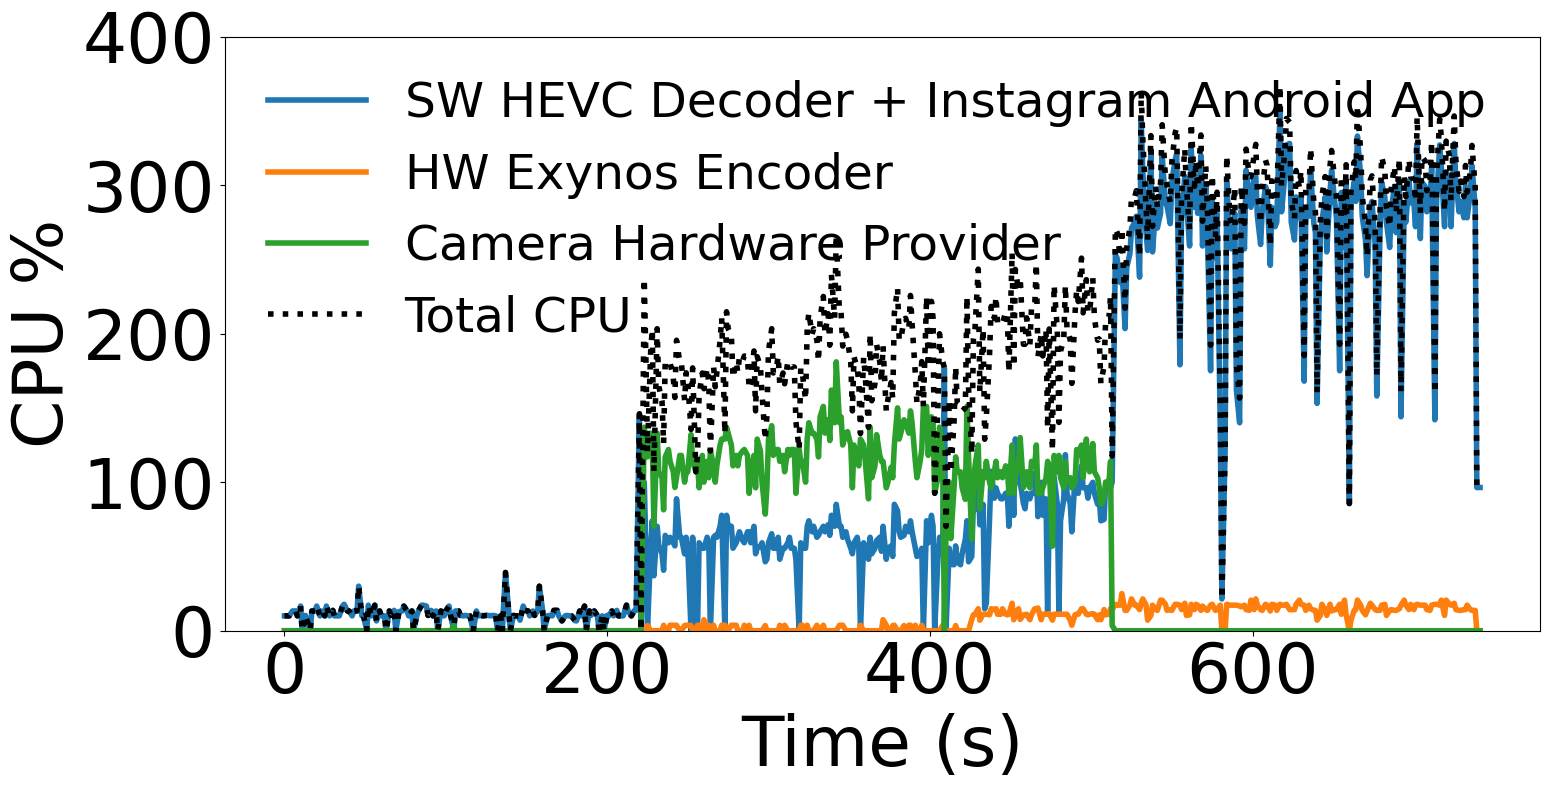

In [6]:
import matplotlib.pyplot as plt
import re
import pandas as pd
from datetime import datetime

# Read the log file
with open('insta_live_codecs_logs.txt', 'r') as f:
    content = f.read()

# Split content into blocks starting with each timestamp
blocks = re.split(r'Timestamp: ', content)[1:]

data = []
for block in blocks:
    lines = block.splitlines()
    if not lines:
        continue

    # Parse timestamp from the first line of the block
    timestamp_str = lines[0].strip()
    try:
        ts = datetime.strptime(timestamp_str, '%a %b %d %H:%M:%S %Z %Y')
    except ValueError:
        continue

    # Extract CPU for each process (assuming multiple process lines)
    for line in lines[1:]:
        stripped_line = line.strip()
        if not stripped_line:
            continue
        parts = re.split(r'\s+', stripped_line)
        if len(parts) > 8 and parts[0].isdigit():
            try:
                pid = int(parts[0])
                cpu = float(parts[8])  # %CPU
                data.append({'time': ts, 'pid': pid, 'cpu': cpu})
            except ValueError:
                pass

# Create DataFrame and sort by time
if not data:
    print("No CPU data found.")
else:
    df = pd.DataFrame(data).sort_values('time')
    df['time_relative'] = (df['time'] - df['time'].min()).dt.total_seconds()
    # df = df[df['time_relative'] >= 40].reset_index(drop=True)

    # Separate Instagram (PID 9979)
    insta_df = df[df['pid'] == 9979][['time_relative', 'cpu']].sort_values('time_relative')
    hw_df = df[df['pid'] == 1020][['time_relative', 'cpu']].sort_values('time_relative')
    hw_cam_df = df[df['pid'] == 978][['time_relative', 'cpu']].sort_values('time_relative')

    # Sum CPU for all other PIDs (Software Codec)
    sw_df = df[df['pid'] != 9979].groupby('time_relative')['cpu'].sum().reset_index().sort_values('time_relative')
    df_filtered = df.drop(df[df['pid'] == 1020].index)
    df_filtered = df_filtered.drop(df[df['pid'] == 978].index)
    # Total CPU
    total_df = df_filtered.groupby('time_relative')['cpu'].sum().reset_index().sort_values('time_relative')
    all_df = df.groupby('time_relative')['cpu'].sum().reset_index().sort_values('time_relative')
    universal_font_size = 50
    # Plot CPU utilization
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.plot(total_df['time_relative'], total_df['cpu'], linewidth=4, label="SW HEVC Decoder + Instagram Android App")
    ax.plot(hw_df['time_relative'], hw_df['cpu'], linewidth=4, label="HW Exynos Encoder")
    ax.plot(hw_cam_df['time_relative'], hw_cam_df['cpu'], linewidth=4, label="Camera Hardware Provider")
    ax.plot(all_df['time_relative'], all_df['cpu'], linewidth=4, label="Total CPU", linestyle=':', color='black')
    ax.set_ylabel('CPU %', fontsize=universal_font_size)
    ax.set_ylim(0, 400)
    ax.set_xlabel('Time (s)', fontsize=universal_font_size)
    ax.tick_params(axis='both', labelsize=universal_font_size)
    ax.legend(fontsize=35, loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()

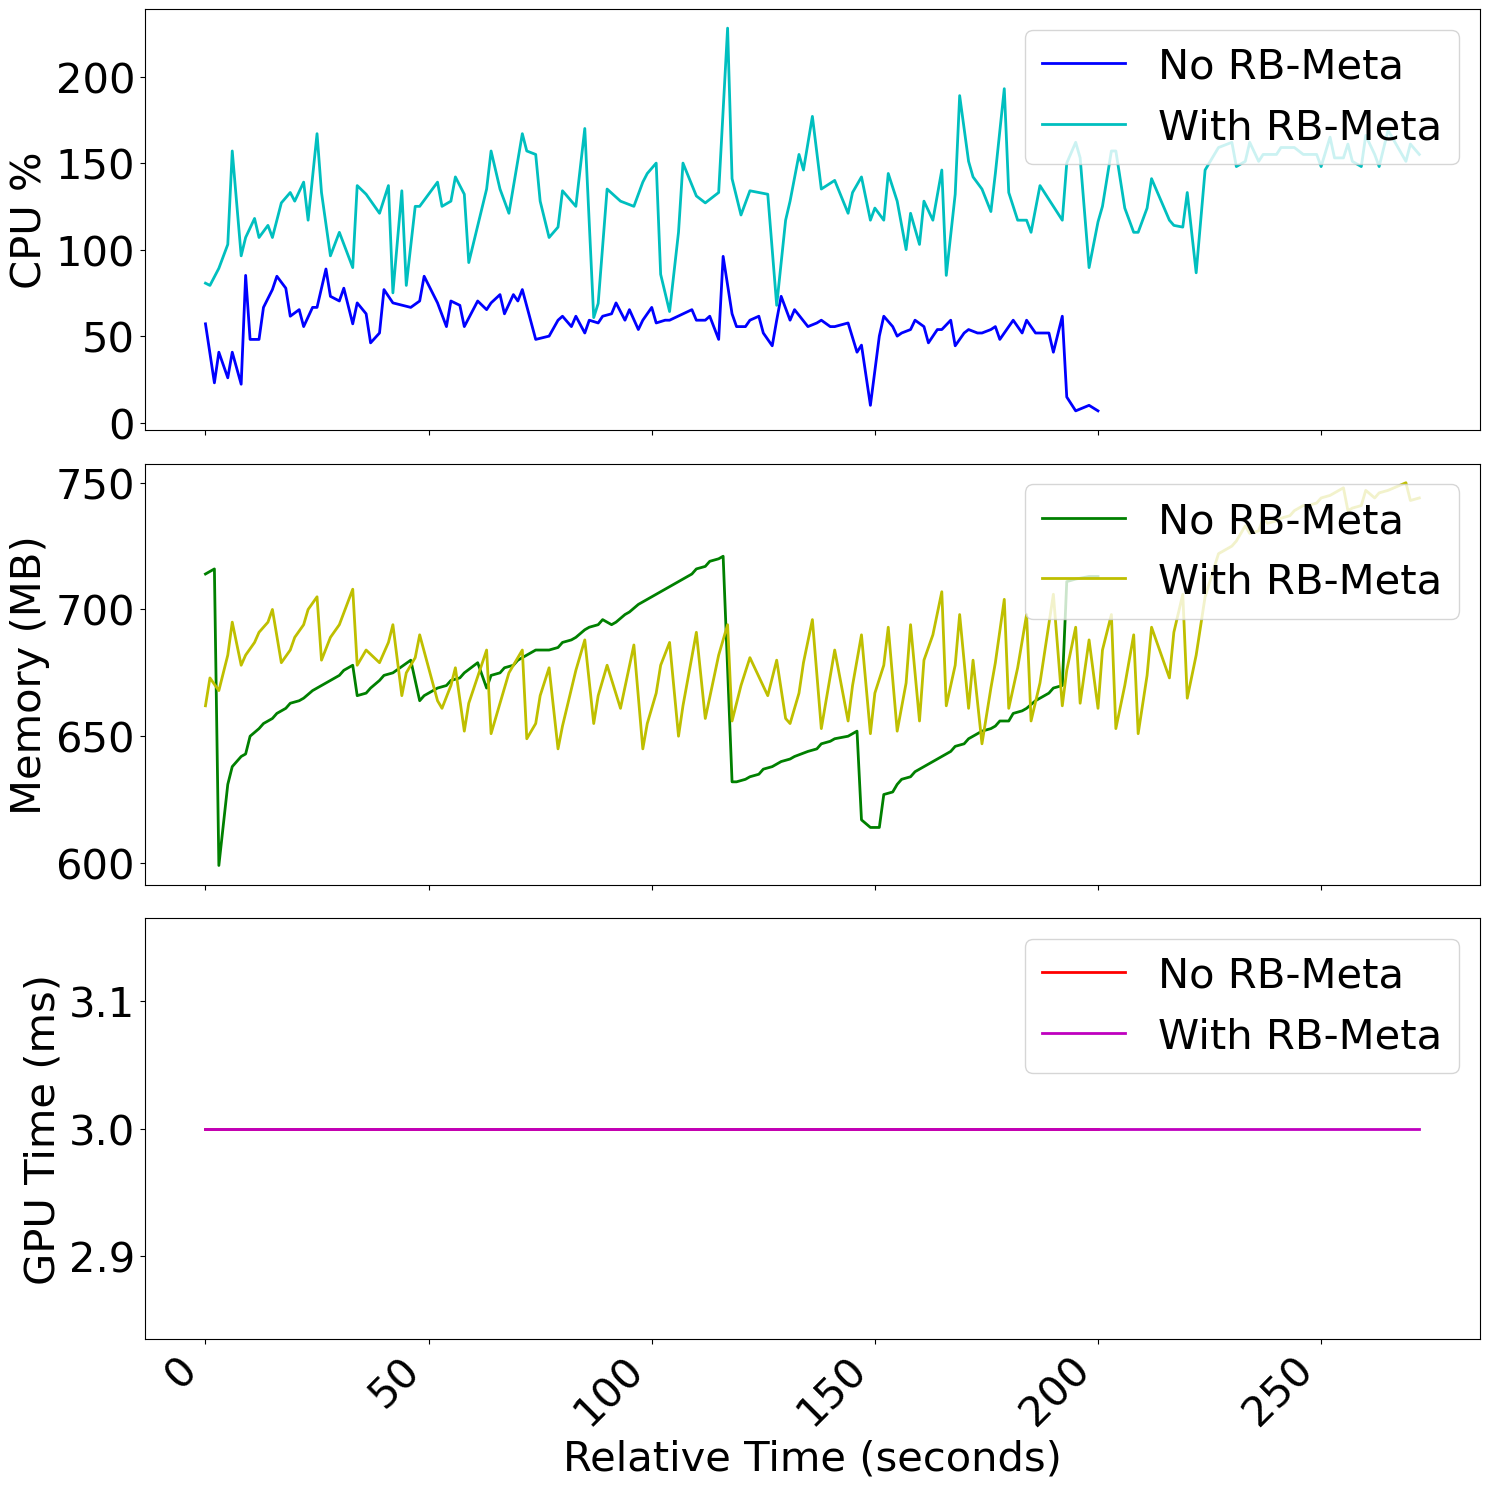

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import re

# Define a function to extract data from a log file
def extract_data_from_log(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    # Split content into blocks starting with each Timestamp
    blocks = re.split(r'Timestamp: ', content)[1:]  # Skip the empty first part

    data = []
    for block in blocks:
        lines = block.splitlines()
        if not lines:
            continue
        
        # Parse timestamp
        timestamp_str = lines[0].strip()
        try:
            ts = datetime.strptime(timestamp_str, '%a %b %d %H:%M:%S %Z %Y')
        except ValueError:
            continue  # Skip invalid timestamps
        
        # Extract CPU and Memory from top output
        cpu = None
        mem_mb = None
        for line in lines:
            stripped_line = line.strip()
            if stripped_line.startswith('4179') and 'com.instagram.a' in stripped_line:
                parts = re.split(r'\s+', stripped_line)
                if len(parts) > 9:
                    try:
                        cpu = float(parts[8])  # %CPU
                        res = parts[5]  # RES
                        if 'M' in res:
                            mem_mb = float(res[:-1])
                        elif 'G' in res:
                            mem_mb = float(res[:-1]) * 1024
                        else:
                            mem_mb = float(res) / 1024  # Assume KB to MB
                    except ValueError:
                        pass
                break
        
        # Extract GPU 50th percentile (as a proxy for GPU utilization in ms)
        gpu_ms = None
        for line in lines:
            if line.startswith('50th gpu percentile:'):
                try:
                    gpu_ms_str = line.split(':')[1].strip()[:-2]  # Remove 'ms'
                    gpu_ms = float(gpu_ms_str)
                except (IndexError, ValueError):
                    pass
                break
        
        if cpu is not None and mem_mb is not None and gpu_ms is not None:
            data.append({'time': ts, 'cpu': cpu, 'mem': mem_mb, 'gpu': gpu_ms})
    
    df = pd.DataFrame(data).sort_values('time')
    df['time_rel'] = (df['time'] - df['time'].min()).dt.total_seconds()
    return df

# Load data from both files
df1 = extract_data_from_log('insta_live_NoG_logs.txt')
df2 = extract_data_from_log('insta_live_G_logs.txt') 

# Create three subplots
fig, axs = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# Plot CPU utilization
axs[0].plot(df1['time_rel'], df1['cpu'], 'b-', linewidth=2, label='No RB-Meta')
axs[0].plot(df2['time_rel'], df2['cpu'], 'c-', linewidth=2, label='With RB-Meta')
axs[0].set_ylabel('CPU %', fontsize=30)
axs[0].tick_params(axis='both', labelsize=30)
axs[0].legend(fontsize=30, loc='upper right')

# Plot Memory utilization (in MB)
axs[1].plot(df1['time_rel'], df1['mem'], 'g-', linewidth=2, label='No RB-Meta')
axs[1].plot(df2['time_rel'], df2['mem'], 'y-', linewidth=2, label='With RB-Meta')
axs[1].set_ylabel('Memory (MB)', fontsize=30)
axs[1].tick_params(axis='both', labelsize=30)
axs[1].legend(fontsize=30, loc='upper right')

# Plot GPU (50th percentile frame time in ms as proxy)
axs[2].plot(df1['time_rel'], df1['gpu'], 'r-', linewidth=2, label='No RB-Meta')
axs[2].plot(df2['time_rel'], df2['gpu'], 'm-', linewidth=2, label='With RB-Meta')
axs[2].set_ylabel('GPU Time (ms)', fontsize=30)
axs[2].set_xlabel('Relative Time (seconds)', fontsize=30)
axs[2].tick_params(axis='both', labelsize=30)
axs[2].legend(fontsize=30, loc='upper right')

# Rotate x-ticks for readability
plt.xticks(rotation=45, ha='right', fontsize=30)

# Adjust layout
plt.tight_layout()
plt.show()

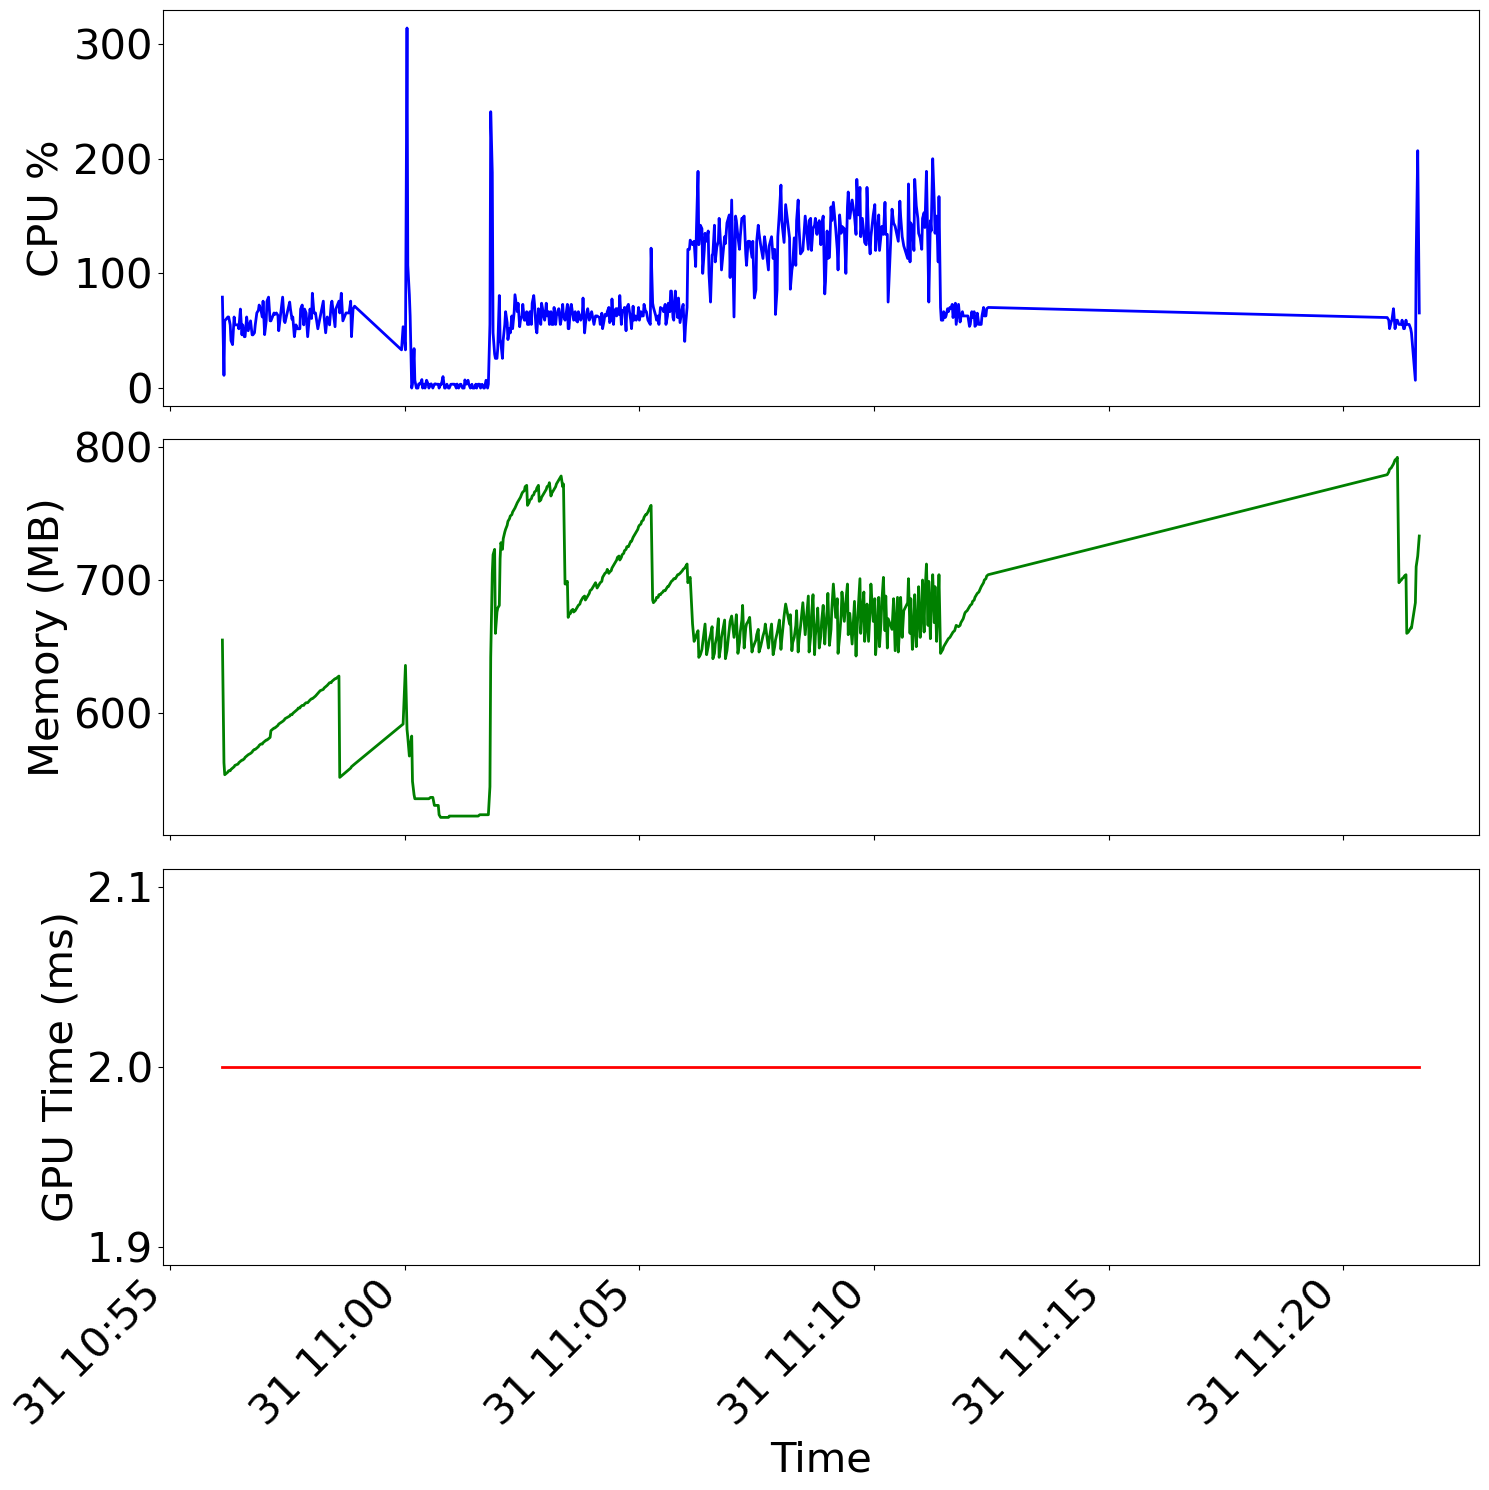

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import re

# Read the log file
with open('insta_live_long_stages_logs.txt', 'r') as f:
    content = f.read()

# Split content into blocks starting with each Timestamp
blocks = re.split(r'Timestamp: ', content)[1:]  # Skip the empty first part

data = []
for block in blocks:
    lines = block.splitlines()
    if not lines:
        continue
    
    # Parse timestamp
    timestamp_str = lines[0].strip()
    try:
        ts = datetime.strptime(timestamp_str, '%a %b %d %H:%M:%S %Z %Y')
    except ValueError:
        continue  # Skip invalid timestamps
    
    # Extract CPU and Memory from top output
    cpu = None
    mem_mb = None
    for line in lines:
        stripped_line = line.strip()
        if stripped_line.startswith('12410') and 'com.instagram.a' in stripped_line:
            parts = re.split(r'\s+', stripped_line)
            if len(parts) > 9:
                try:
                    cpu = float(parts[8])  # %CPU
                    res = parts[5]  # RES
                    if 'M' in res:
                        mem_mb = float(res[:-1])
                    elif 'G' in res:
                        mem_mb = float(res[:-1]) * 1024
                    else:
                        mem_mb = float(res) / 1024  # Assume KB to MB
                except ValueError:
                    pass
            break
    
    # Extract GPU 50th percentile (as a proxy for GPU utilization in ms)
    gpu_ms = None
    for line in lines:
        if line.startswith('50th gpu percentile:'):
            try:
                gpu_ms_str = line.split(':')[1].strip()[:-2]  # Remove 'ms'
                gpu_ms = float(gpu_ms_str)
            except (IndexError, ValueError):
                pass
            break
    
    if cpu is not None and mem_mb is not None and gpu_ms is not None:
        data.append({'time': ts, 'cpu': cpu, 'mem': mem_mb, 'gpu': gpu_ms})

# Create DataFrame and sort by time
df = pd.DataFrame(data)
df = df.sort_values('time')

# Create three subplots
fig, axs = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# Plot CPU utilization
axs[0].plot(df['time'], df['cpu'], 'b-', linewidth=2)
axs[0].set_ylabel('CPU %', fontsize=30)
axs[0].tick_params(axis='both', labelsize=30)

# Plot Memory utilization (in MB)
axs[1].plot(df['time'], df['mem'], 'g-', linewidth=2)
axs[1].set_ylabel('Memory (MB)', fontsize=30)
axs[1].tick_params(axis='both', labelsize=30)

# Plot GPU (50th percentile frame time in ms as proxy)
axs[2].plot(df['time'], df['gpu'], 'r-', linewidth=2)
axs[2].set_ylabel('GPU Time (ms)', fontsize=30)
axs[2].set_xlabel('Time', fontsize=30)
axs[2].tick_params(axis='both', labelsize=30)

# Rotate x-ticks for readability
plt.xticks(rotation=45, ha='right', fontsize=30)

# Adjust layout
plt.tight_layout()
plt.show()

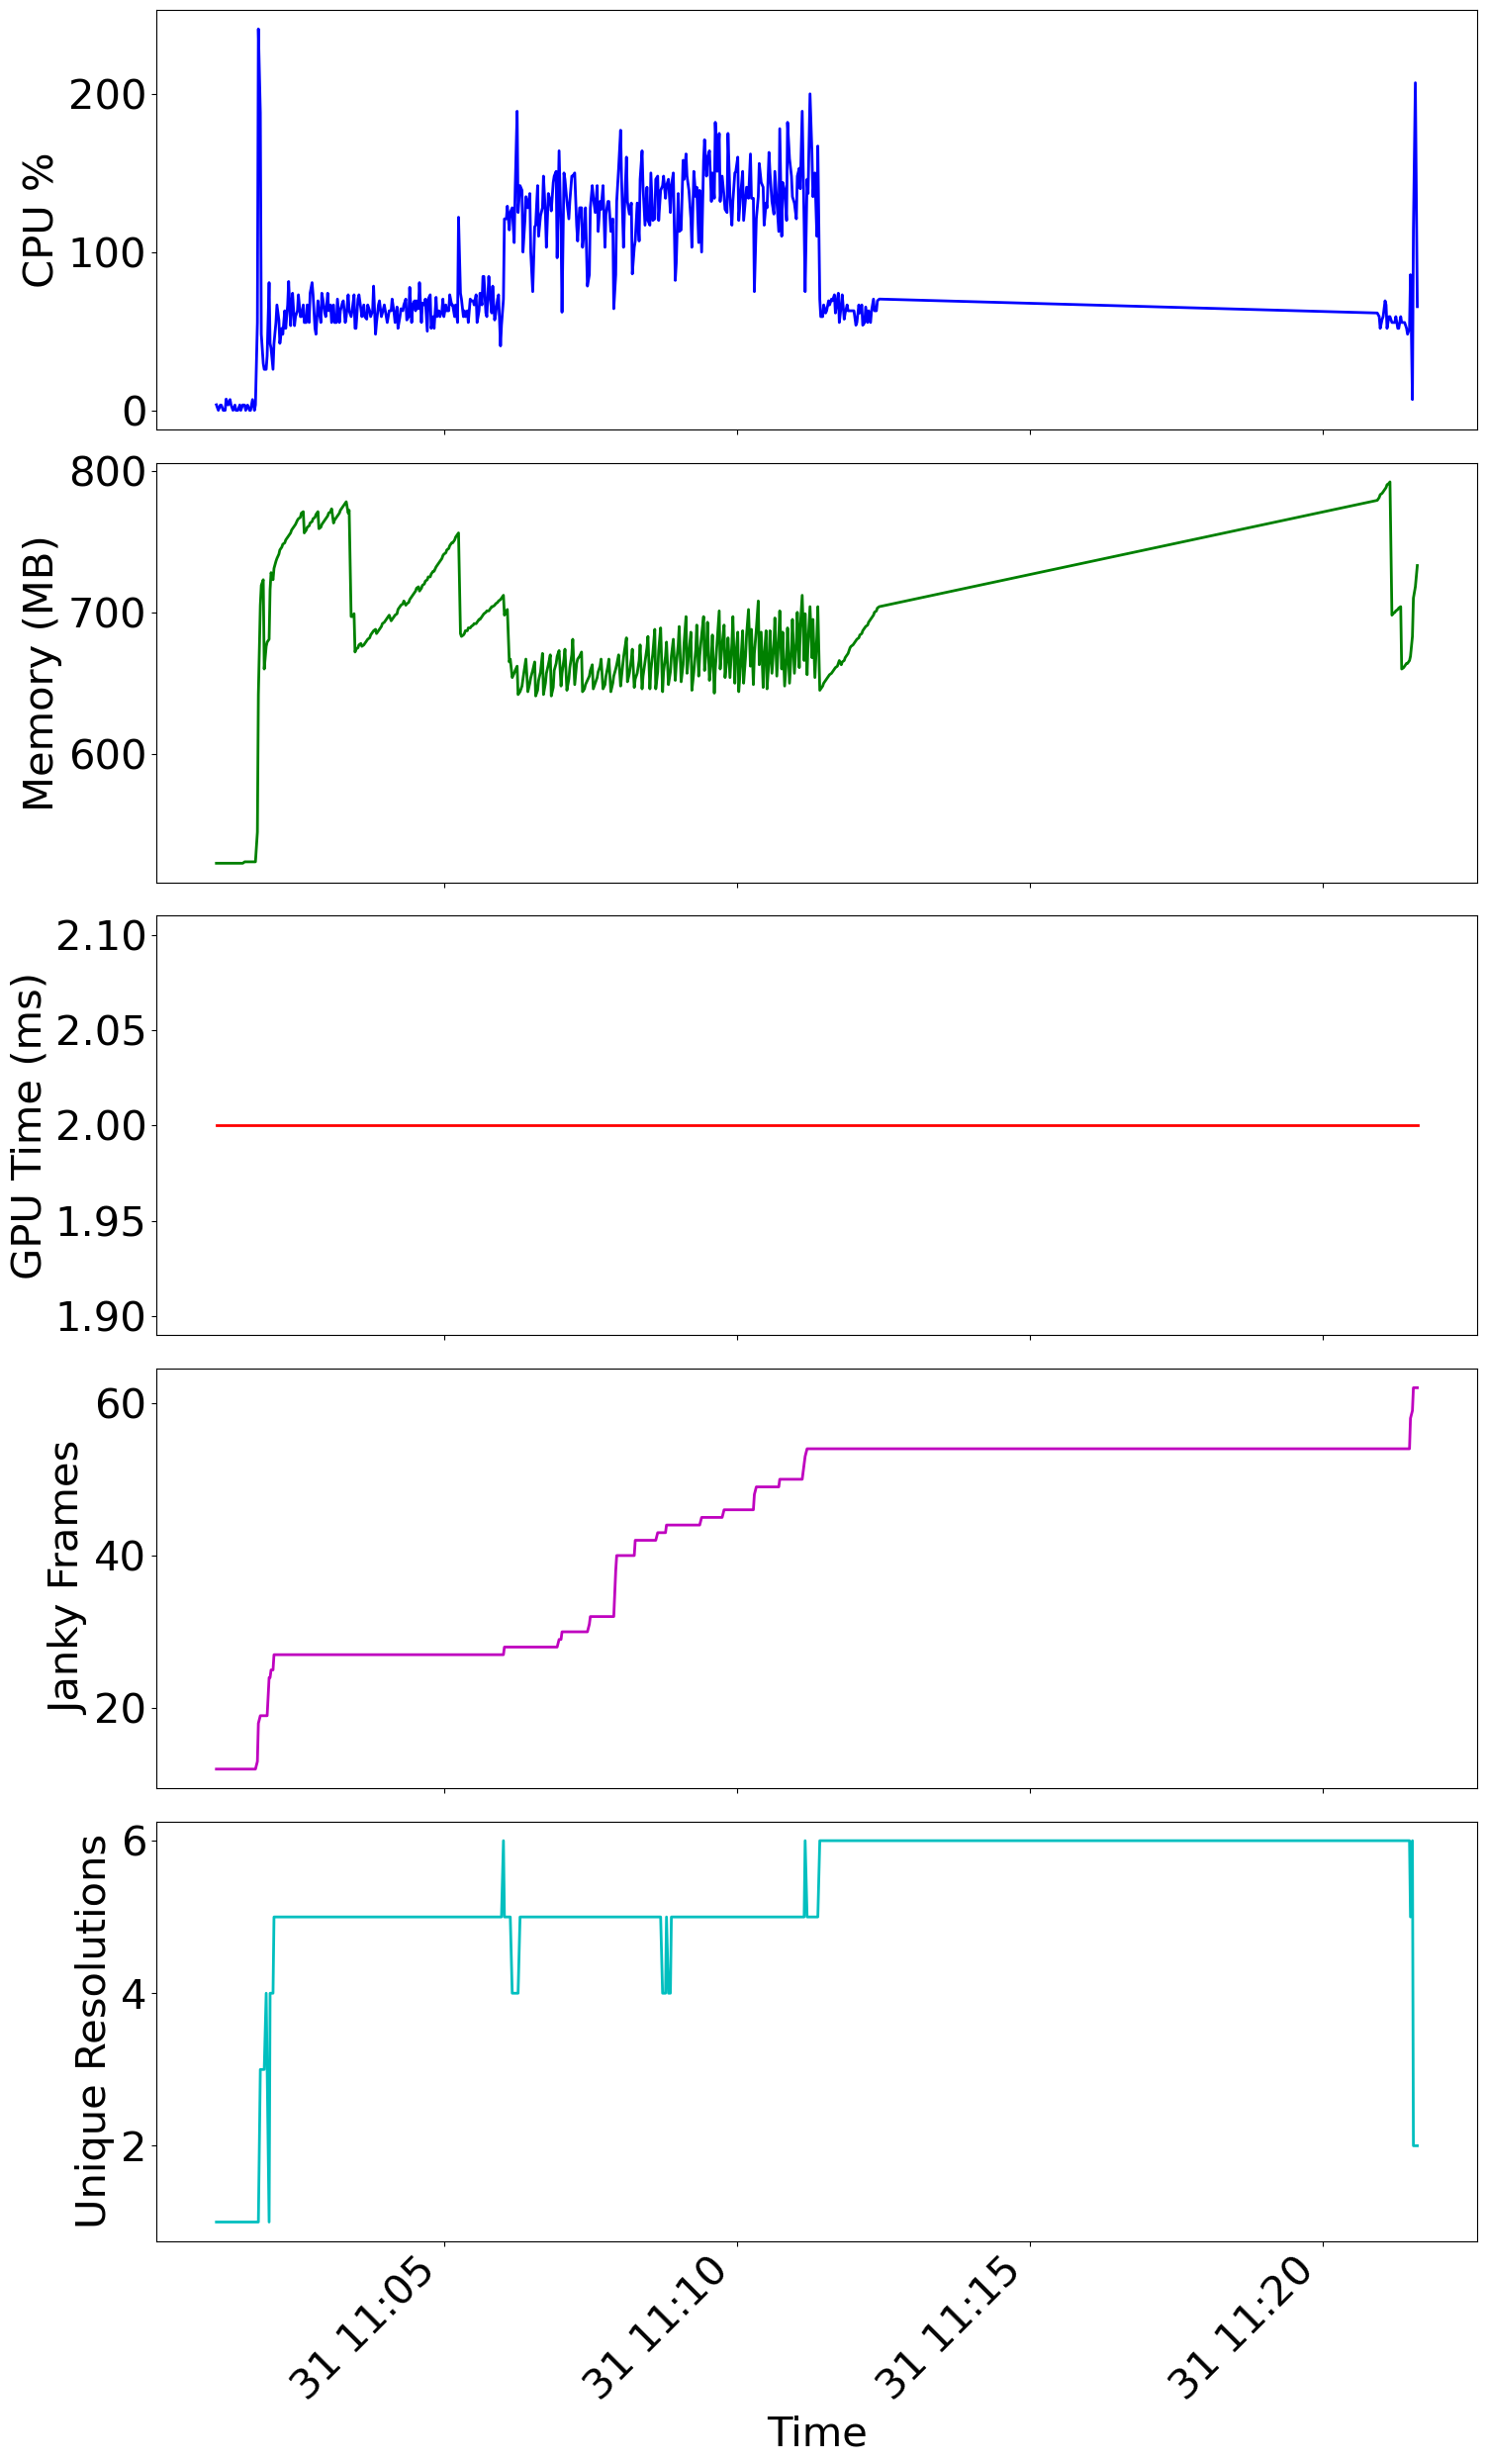

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import re
from datetime import timedelta

# Read the log file
with open('insta_live_long_stages_logs.txt', 'r') as f:
    content = f.read()

# Clean ANSI sequences to avoid parsing issues
content = re.sub(r'\x1b\[.*?m', '', content)
content = re.sub(r'\x1b\[[0-?]*[ -/]*[@-~]', '', content)

# Split content into blocks starting with each Timestamp
blocks = re.split(r'Timestamp: ', content)[1:]  # Skip the empty first part

data = []
for block in blocks:
    lines = block.splitlines()
    if not lines:
        continue
    
    # Parse timestamp
    timestamp_str = lines[0].strip()
    try:
        ts = datetime.strptime(timestamp_str, '%a %b %d %H:%M:%S %Z %Y')
    except ValueError:
        continue  # Skip invalid timestamps
    
    # Extract CPU and Memory from top output
    cpu = None
    mem_mb = None
    for line in lines:
        stripped_line = line.strip()
        if stripped_line.startswith('12410') and 'com.instagram.a' in stripped_line:
            parts = re.split(r'\s+', stripped_line)
            if len(parts) > 9:
                try:
                    cpu = float(parts[8])  # %CPU
                    res = parts[5]  # RES
                    if 'M' in res:
                        mem_mb = float(res[:-1])
                    elif 'G' in res:
                        mem_mb = float(res[:-1]) * 1024
                    else:
                        mem_mb = float(res) / 1024  # Assume KB to MB
                except ValueError:
                    pass
            break
    
    # Extract GPU 50th percentile (as a proxy for GPU utilization in ms)
    gpu_ms = None
    for line in lines:
        if line.startswith('50th gpu percentile:'):
            try:
                gpu_ms_str = line.split(':')[1].strip()[:-2]  # Remove 'ms'
                gpu_ms = float(gpu_ms_str)
            except (IndexError, ValueError):
                pass
            break
    
    # Extract Janky frames
    janky = None
    for line in lines:
        if line.startswith('Janky frames:'):
            match = re.match(r'Janky frames: (\d+) ', line)
            if match:
                janky = int(match.group(1))
            break
    
    # Extract unique resolutions from GraphicBufferAllocator buffers
    buffers_start = None
    for i, line in enumerate(lines):
        if line.strip() == 'GraphicBufferAllocator buffers:':
            buffers_start = i + 2  # Skip header
            break
    
    unique_res = 0
    if buffers_start is not None:
        res_set = set()
        for line in lines[buffers_start:]:
            if line.strip().startswith('Total allocated'):
                break
            if '|' in line:
                parts = [p.strip() for p in line.split('|')]
                if len(parts) > 3:
                    dim = parts[2]  # e.g., '1280 (1280) x  720'
                    res_set.add(dim)
        unique_res = len(res_set)
    
    if cpu is not None and mem_mb is not None and gpu_ms is not None and janky is not None and unique_res != 0:
        data.append({'time': ts, 'cpu': cpu, 'mem': mem_mb, 'gpu': gpu_ms, 'janky': janky, 'unique_res': unique_res})

# Create DataFrame and sort by time
df = pd.DataFrame(data)
df = df.sort_values('time')

# Exclude the first five minutes
if not df.empty:
    min_time = df['time'].min()
    cutoff = min_time + timedelta(minutes=5)
    df = df[df['time'] >= cutoff]

# Create five subplots
fig, axs = plt.subplots(5, 1, figsize=(15, 25), sharex=True)

# Plot CPU utilization
axs[0].plot(df['time'], df['cpu'], 'b-', linewidth=2)
axs[0].set_ylabel('CPU %', fontsize=30)
axs[0].tick_params(axis='both', labelsize=30)

# Plot Memory utilization (in MB)
axs[1].plot(df['time'], df['mem'], 'g-', linewidth=2)
axs[1].set_ylabel('Memory (MB)', fontsize=30)
axs[1].tick_params(axis='both', labelsize=30)

# Plot GPU (50th percentile frame time in ms as proxy)
axs[2].plot(df['time'], df['gpu'], 'r-', linewidth=2)
axs[2].set_ylabel('GPU Time (ms)', fontsize=30)
axs[2].tick_params(axis='both', labelsize=30)

# Plot Janky frames
axs[3].plot(df['time'], df['janky'], 'm-', linewidth=2)
axs[3].set_ylabel('Janky Frames', fontsize=30)
axs[3].tick_params(axis='both', labelsize=30)

# Plot Unique Buffer Resolutions
axs[4].plot(df['time'], df['unique_res'], 'c-', linewidth=2)
axs[4].set_ylabel('Unique Resolutions', fontsize=30)
axs[4].tick_params(axis='both', labelsize=30)

# Set x-label on the last subplot
axs[4].set_xlabel('Time', fontsize=30)

# Rotate x-ticks for readability
plt.xticks(rotation=45, ha='right', fontsize=30)

# Adjust layout
plt.tight_layout()
plt.show()

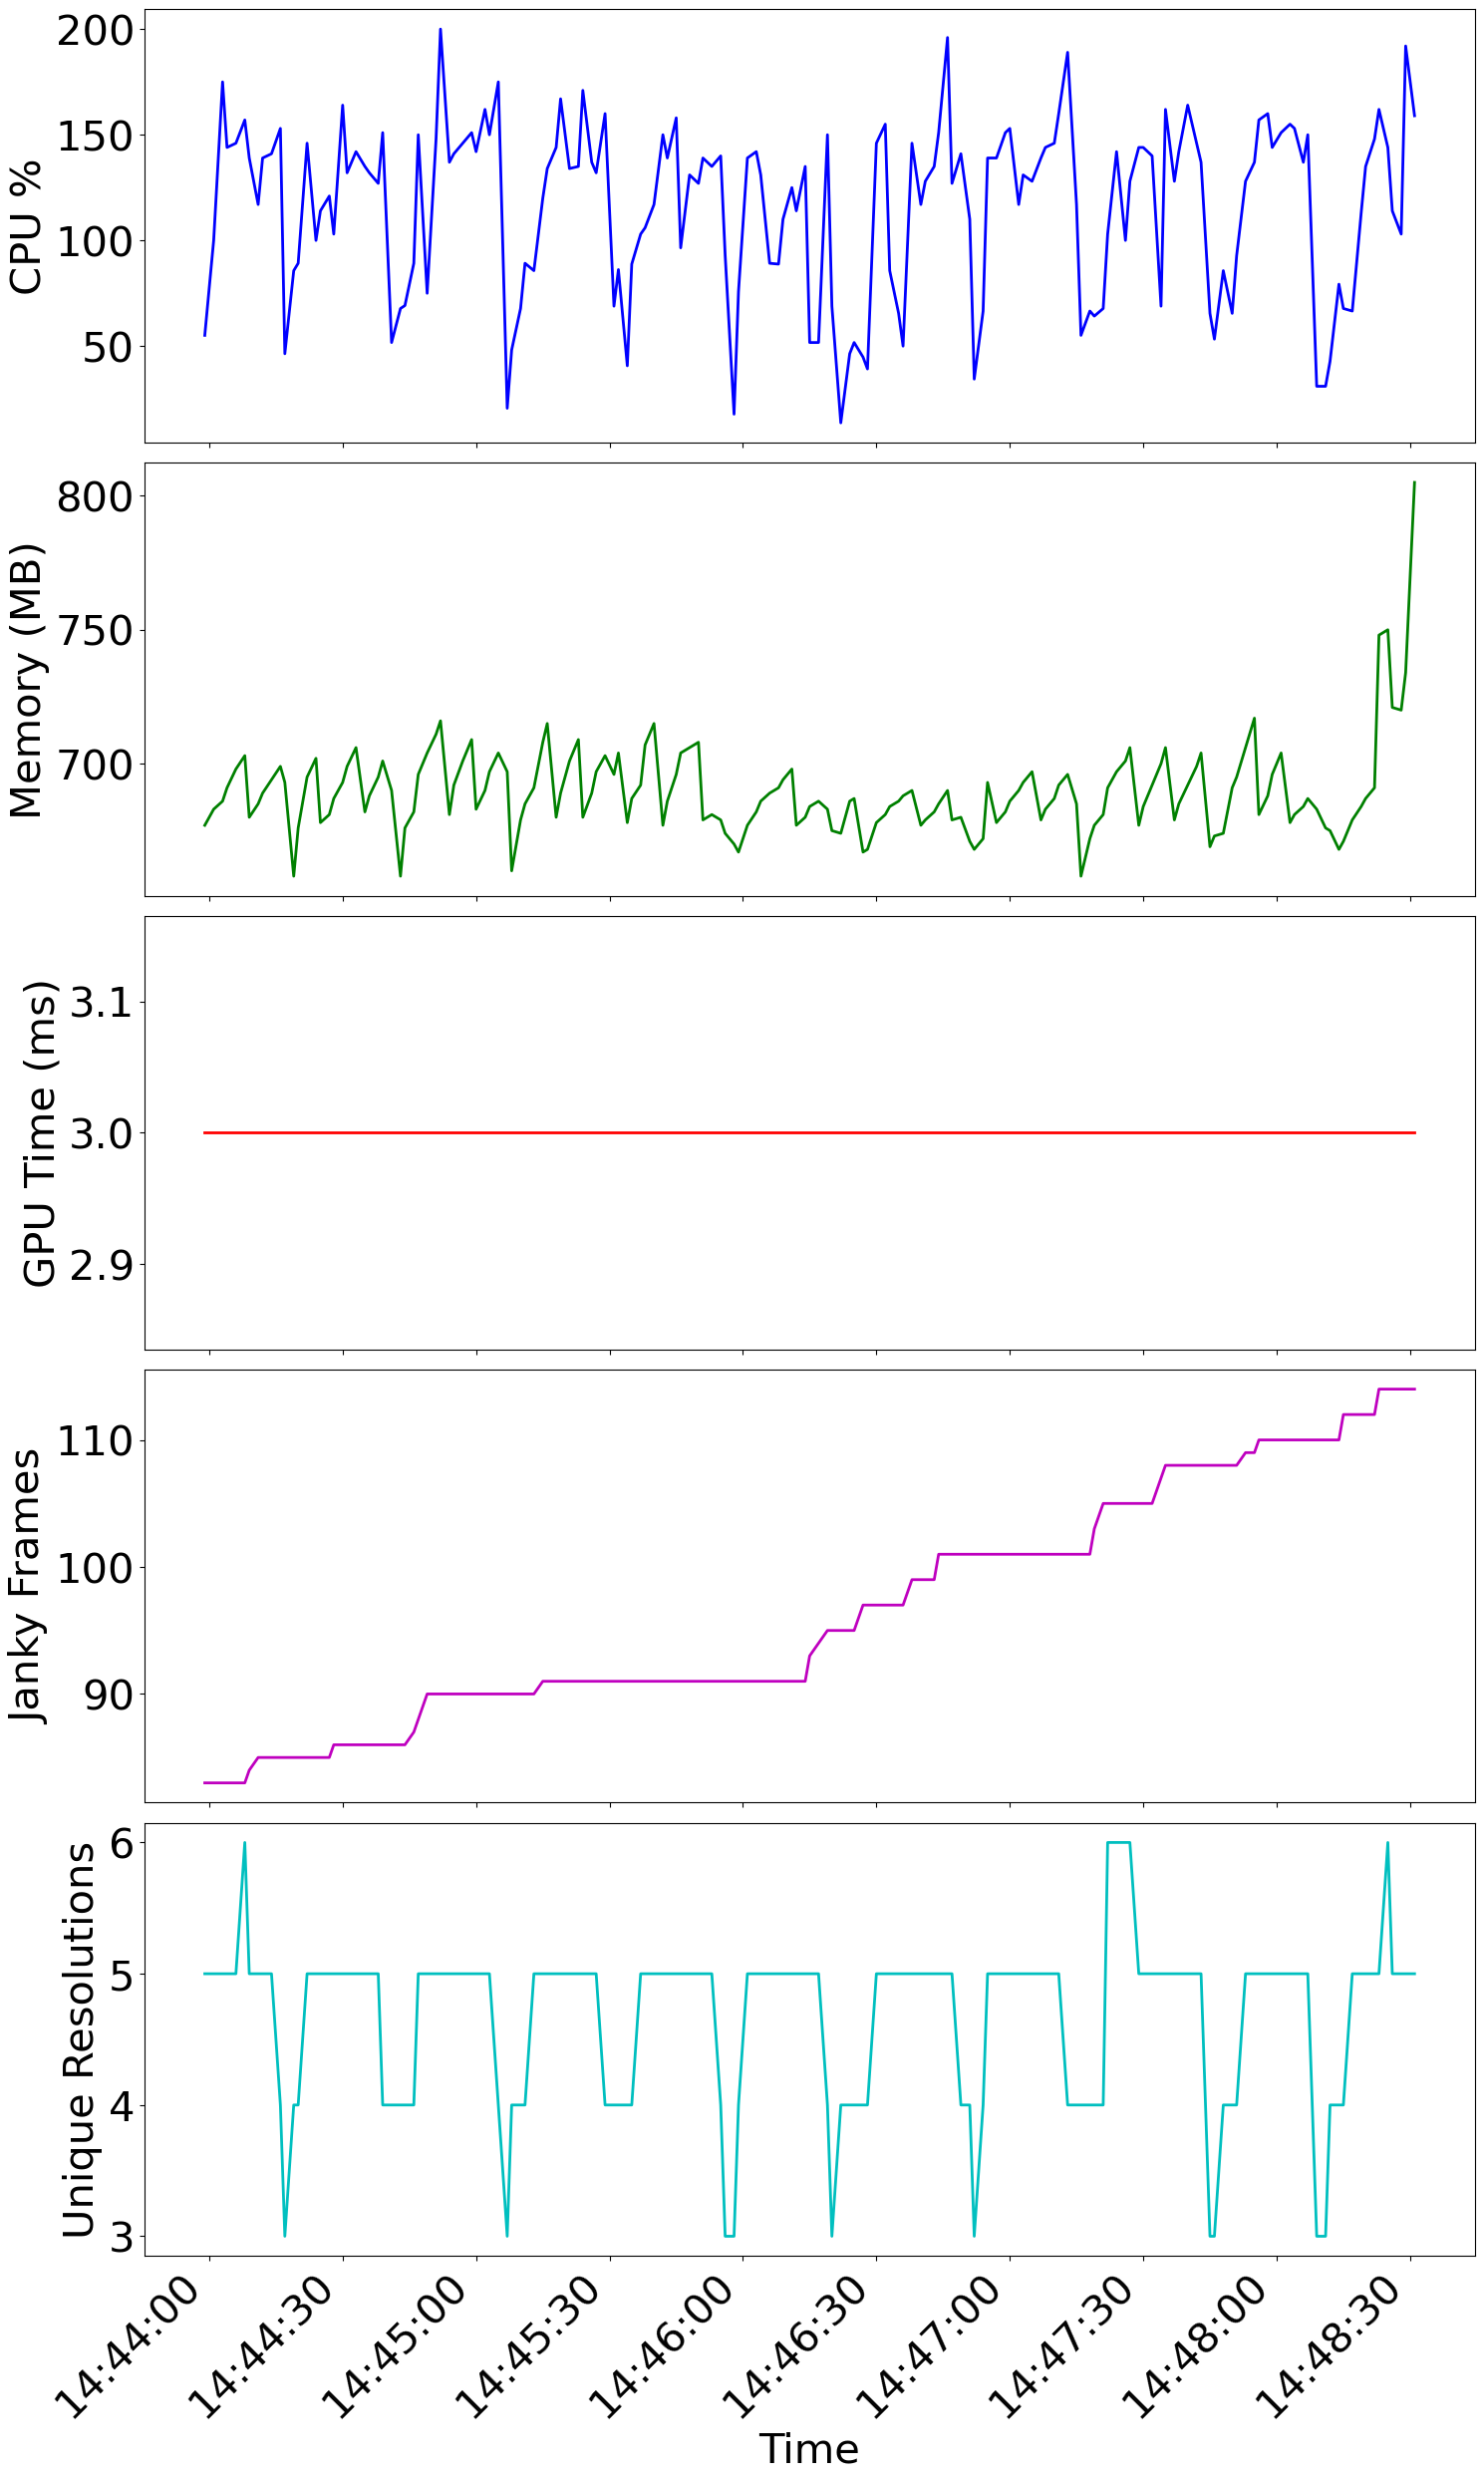

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import re
from datetime import timedelta

# Read the log file
with open('insta_live_WD_30m_logs.txt', 'r') as f:
    content = f.read()

# Clean ANSI sequences to avoid parsing issues
content = re.sub(r'\x1b\[.*?m', '', content)
content = re.sub(r'\x1b\[[0-?]*[ -/]*[@-~]', '', content)

# Split content into blocks starting with each Timestamp
blocks = re.split(r'Timestamp: ', content)[1:]  # Skip the empty first part

data = []
for block in blocks:
    lines = block.splitlines()
    if not lines:
        continue
    
    # Parse timestamp
    timestamp_str = lines[0].strip()
    try:
        ts = datetime.strptime(timestamp_str, '%a %b %d %H:%M:%S %Z %Y')
    except ValueError:
        continue  # Skip invalid timestamps
    
    # Extract CPU and Memory from top output
    cpu = None
    mem_mb = None
    for line in lines:
        stripped_line = line.strip()
        if stripped_line.startswith('13426') and 'com.instagram.a' in stripped_line:
            parts = re.split(r'\s+', stripped_line)
            if len(parts) > 9:
                try:
                    cpu = float(parts[8])  # %CPU
                    res = parts[5]  # RES
                    if 'M' in res:
                        mem_mb = float(res[:-1])
                    elif 'G' in res:
                        mem_mb = float(res[:-1]) * 1024
                    else:
                        mem_mb = float(res) / 1024  # Assume KB to MB
                except ValueError:
                    pass
            break
    
    # Extract GPU 50th percentile (as a proxy for GPU utilization in ms)
    gpu_ms = None
    for line in lines:
        if line.startswith('50th gpu percentile:'):
            try:
                gpu_ms_str = line.split(':')[1].strip()[:-2]  # Remove 'ms'
                gpu_ms = float(gpu_ms_str)
            except (IndexError, ValueError):
                pass
            break
    
    # Extract Janky frames
    janky = None
    for line in lines:
        if line.startswith('Janky frames:'):
            match = re.match(r'Janky frames: (\d+) ', line)
            if match:
                janky = int(match.group(1))
            break
    
    # Extract unique resolutions from GraphicBufferAllocator buffers
    buffers_start = None
    for i, line in enumerate(lines):
        if line.strip() == 'GraphicBufferAllocator buffers:':
            buffers_start = i + 2  # Skip header
            break
    
    unique_res = 0
    if buffers_start is not None:
        res_set = set()
        for line in lines[buffers_start:]:
            if line.strip().startswith('Total allocated'):
                break
            if '|' in line:
                parts = [p.strip() for p in line.split('|')]
                if len(parts) > 3:
                    dim = parts[2]  # e.g., '1280 (1280) x  720'
                    res_set.add(dim)
        unique_res = len(res_set)
    
    if cpu is not None and mem_mb is not None and gpu_ms is not None and janky is not None and unique_res != 0:
        data.append({'time': ts, 'cpu': cpu, 'mem': mem_mb, 'gpu': gpu_ms, 'janky': janky, 'unique_res': unique_res})

# Create DataFrame and sort by time
df = pd.DataFrame(data)
df = df.sort_values('time')

# Exclude the first five minutes
# if not df.empty:
#     min_time = df['time'].min()
#     cutoff = min_time + timedelta(minutes=5)
#     df = df[df['time'] >= cutoff]

# Create five subplots
fig, axs = plt.subplots(5, 1, figsize=(15, 25), sharex=True)

# Plot CPU utilization
axs[0].plot(df['time'], df['cpu'], 'b-', linewidth=2)
axs[0].set_ylabel('CPU %', fontsize=30)
axs[0].tick_params(axis='both', labelsize=30)

# Plot Memory utilization (in MB)
axs[1].plot(df['time'], df['mem'], 'g-', linewidth=2)
axs[1].set_ylabel('Memory (MB)', fontsize=30)
axs[1].tick_params(axis='both', labelsize=30)

# Plot GPU (50th percentile frame time in ms as proxy)
axs[2].plot(df['time'], df['gpu'], 'r-', linewidth=2)
axs[2].set_ylabel('GPU Time (ms)', fontsize=30)
axs[2].tick_params(axis='both', labelsize=30)

# Plot Janky frames
axs[3].plot(df['time'], df['janky'], 'm-', linewidth=2)
axs[3].set_ylabel('Janky Frames', fontsize=30)
axs[3].tick_params(axis='both', labelsize=30)

# Plot Unique Buffer Resolutions
axs[4].plot(df['time'], df['unique_res'], 'c-', linewidth=2)
axs[4].set_ylabel('Unique Resolutions', fontsize=30)
axs[4].tick_params(axis='both', labelsize=30)

# Set x-label on the last subplot
axs[4].set_xlabel('Time', fontsize=30)

# Rotate x-ticks for readability
plt.xticks(rotation=45, ha='right', fontsize=30)

# Adjust layout
plt.tight_layout()
plt.show()